In [1]:
# Decision Tree on Bank Marketing Dataset

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
from sklearn import tree

In [3]:
# 1. Load the dataset
df = pd.read_csv("bank-full.csv", sep=";")   # use bank.csv for smaller sample

In [4]:
print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (45211, 17)
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  


In [5]:
#2. Encode categorical variables
df_encoded = df.copy()
label_encoders = {}

for column in df_encoded.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df_encoded[column] = le.fit_transform(df_encoded[column])
    label_encoders[column] = le

In [6]:
 #3. Split data into features/target
 X = df_encoded.drop(columns=['y'])
y = df_encoded['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [7]:
# 4. Train Decision Tree
clf = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,        # limit depth to avoid overfitting
    random_state=42
)
clf.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

In [10]:
# Step 6: Make Predictions
y_pred = clf.predict(X_test)

In [14]:
#Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", round(accuracy, 4), "\n")


Model Accuracy: 0.8901 



In [8]:
# 5. Predictions & Evaluation
y_pred = clf.predict(X_test)

print("\nModel Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))



Model Accuracy: 0.8900766735476261

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.98      0.94     11977
           1       0.57      0.24      0.34      1587

    accuracy                           0.89     13564
   macro avg       0.74      0.61      0.64     13564
weighted avg       0.87      0.89      0.87     13564


Confusion Matrix:
 [[11691   286]
 [ 1205   382]]


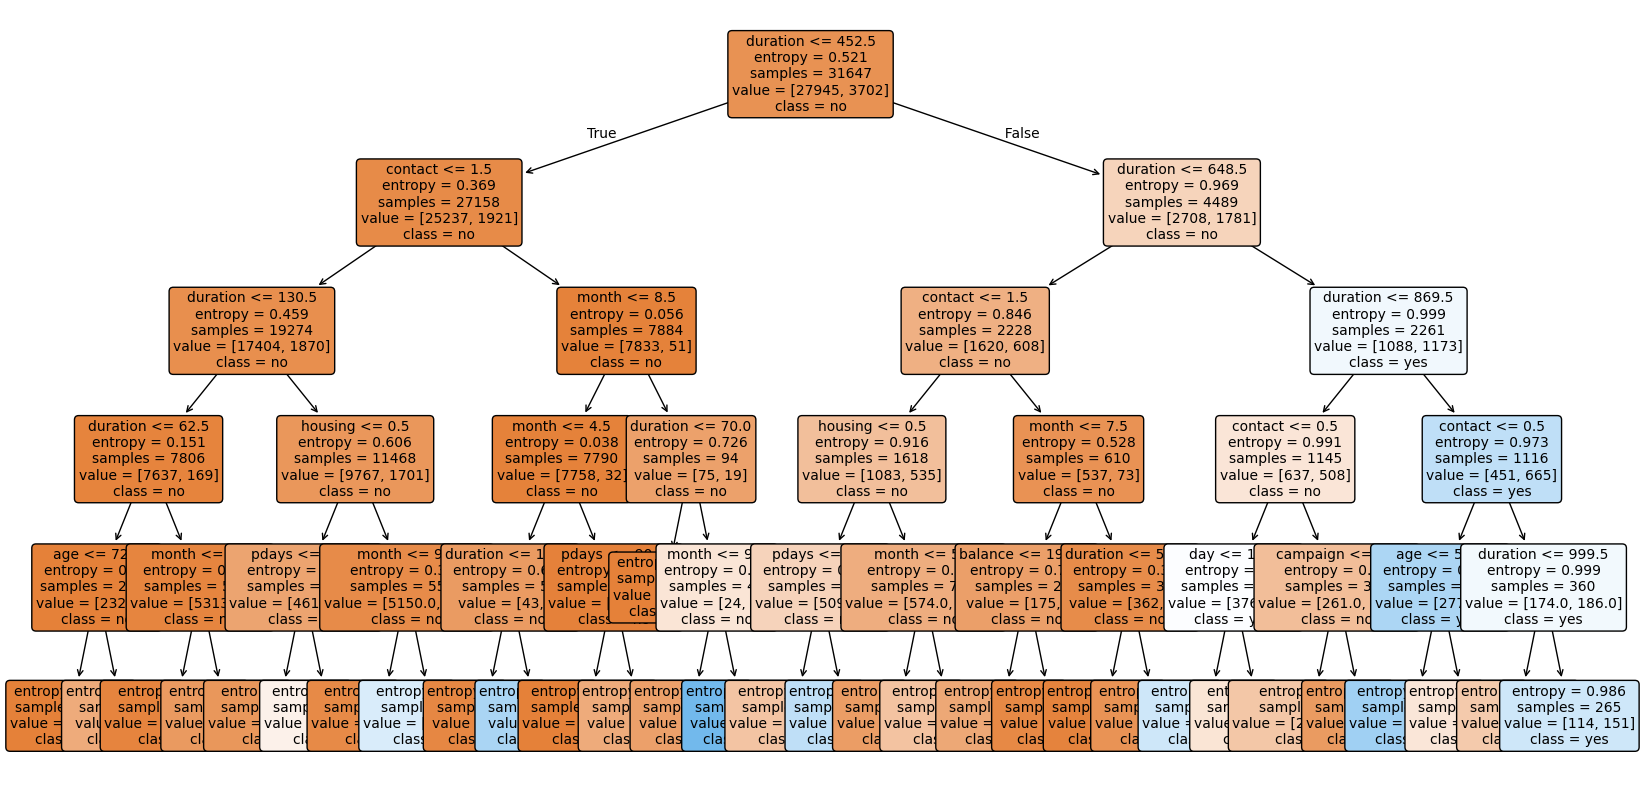

In [9]:
# 6. Visualize Decision Tree
plt.figure(figsize=(20,10))
tree.plot_tree(clf,
               feature_names=X.columns,
               class_names=label_encoders['y'].classes_,
               filled=True,
               rounded=True,
               fontsize=10)
plt.show()